# Task 3: Sentiment Analysis and Correlation

This notebook implements the pipeline for:
1. Sentiment scoring of news headlines using VADER.
2. Aggregating sentiment scores by date and stock.
3. Calculating daily stock returns.
4. Correlating sentiment with returns.

In [8]:
import sys
import os
import importlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Add the project root to the path so we can import from src
sys.path.append(os.path.abspath(os.path.join('..')))

import src.sentiment_analysis as sentiment_analysis
import src.stock_data as stock_data
importlib.reload(sentiment_analysis)
importlib.reload(stock_data)
from src.sentiment_analysis import analyze_sentiment, aggregate_sentiment
from src.stock_data import load_stock_csv

%matplotlib inline
sns.set(style='whitegrid')

In [9]:
# Load News Data
news_path = '../data/raw_analyst_ratings.csv'
df_news = pd.read_csv(news_path)

# Display first few rows
print("News Data Head:")
display(df_news.head())

# Analyze Sentiment
print("\nAnalyzing Sentiment...")
df_news = analyze_sentiment(df_news, text_column='headline')

# Aggregate Sentiment by Date and Stock
print("Aggregating Sentiment...")
sentiment_daily = aggregate_sentiment(df_news, date_column='date', stock_column='stock')

print("\nDaily Sentiment Head:")
display(sentiment_daily.head())

News Data Head:


,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A



Analyzing Sentiment...
Aggregating Sentiment...
Aggregating Sentiment...

Daily Sentiment Head:

Daily Sentiment Head:


stock,A,AA,AAC,AADR,AAL,AAMC,AAME,AAN,AAOI,AAON,...,ZOES,ZPIN,ZQK,ZSL,ZSPH,ZTR,ZTS,ZU,ZUMZ,ZX
normalized_date,,,,,,,,,,,,,,,,,,,,,
2011-04-28,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-04-29,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-04-30,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-05-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-05-02,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [10]:
# Load Stock Data
tickers = ['AAPL', 'AMZN', 'GOOG', 'META', 'MSFT', 'NVDA']
start_date = '2020-01-01'
end_date = '2023-12-31' # Adjust as needed based on data availability

stock_returns = pd.DataFrame()

for ticker in tickers:
    try:
        # Load local CSV if available
        csv_path = f'../data/{ticker}.csv'
        if os.path.exists(csv_path):
            df_stock = load_stock_csv(csv_path)
        else:
            print(f"Data for {ticker} not found locally.")
            continue
            
        # Calculate Daily Returns
        # Ensure index is datetime
        df_stock.index = pd.to_datetime(df_stock.index, utc=True)
        
        # Calculate returns: (Price_t - Price_t-1) / Price_t-1
        # We use 'Adj Close' if available, else 'Close'
        price_col = 'Adj Close' if 'Adj Close' in df_stock.columns else 'Close'
        returns = df_stock[price_col].pct_change()
        
        stock_returns[ticker] = returns
        
    except Exception as e:
        print(f"Error processing {ticker}: {e}")

print("\nStock Returns Head:")
display(stock_returns.head())

Loading data from ../data/AAPL.csv...
Loading data from ../data/AMZN.csv...
Loading data from ../data/GOOG.csv...
Loading data from ../data/META.csv...
Loading data from ../data/MSFT.csv...
Loading data from ../data/NVDA.csv...

Stock Returns Head:


,AAPL,AMZN,GOOG,META,MSFT,NVDA
Date,,,,,,
2009-01-02 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN
2009-01-05 00:00:00+00:00,0.042204,-0.005519,0.020945,NaN,0.009345,0.018370
2009-01-06 00:00:00+00:00,-0.016494,0.061043,0.018321,NaN,0.011696,0.033822
2009-01-07 00:00:00+00:00,-0.021609,-0.020223,-0.036071,NaN,-0.060211,-0.059978
2009-01-08 00:00:00+00:00,0.018570,0.017082,0.009875,NaN,0.031266,-0.025522


Aligned Data Points: 2222
AAPL -> Pearson: 0.0470, Spearman: 0.0471


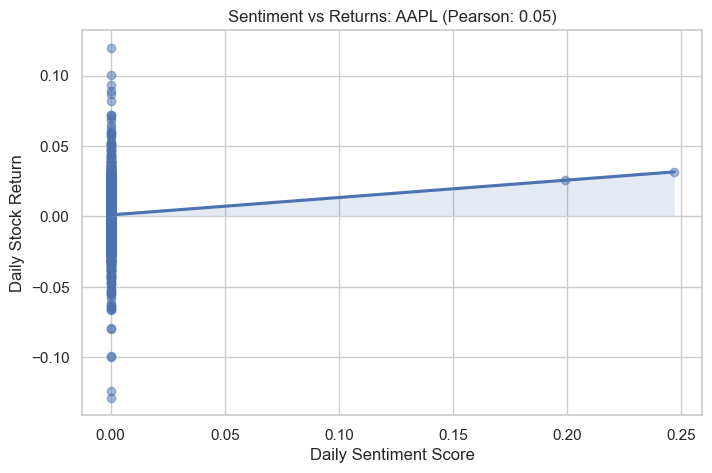

AMZN -> Pearson: 0.0238, Spearman: 0.0426


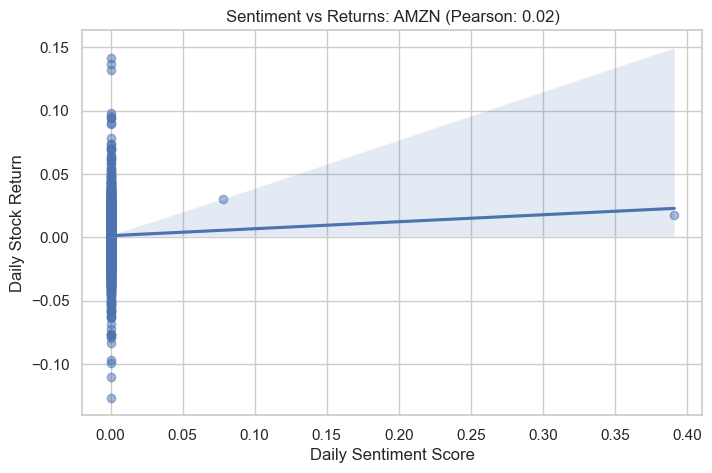

GOOG -> Pearson: -0.0052, Spearman: -0.0018


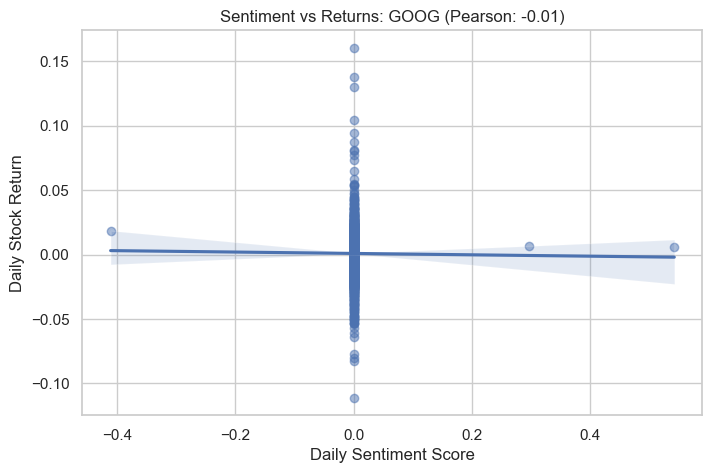

NVDA -> Pearson: 0.0243, Spearman: 0.0207


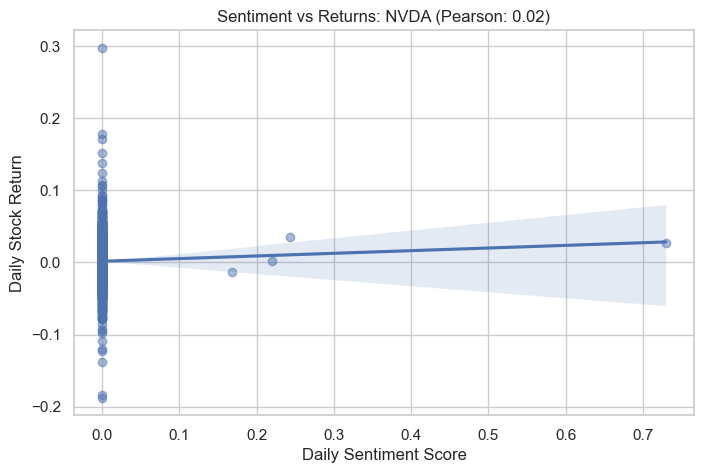


Correlation Summary:


,Pearson,Spearman
Ticker,,
AAPL,0.046953,0.047098
AMZN,0.023821,0.042627
GOOG,-0.005185,-0.001817
NVDA,0.024268,0.020746


In [12]:
# Align Data and Calculate Correlation
correlation_rows = []

# Ensure indices are normalized to date (no time) for alignment
sentiment_index = pd.to_datetime(sentiment_daily.index)
if sentiment_index.tz is not None:
    sentiment_index = sentiment_index.tz_convert(None)
sentiment_daily.index = sentiment_index.normalize()

stock_index = pd.to_datetime(stock_returns.index)
if stock_index.tz is not None:
    stock_index = stock_index.tz_convert(None)
stock_returns.index = stock_index.normalize()

aligned_dates = sentiment_daily.index.intersection(stock_returns.index)
print(f"Aligned Data Points: {len(aligned_dates)}")

for ticker in tickers:
    if ticker in sentiment_daily.columns and ticker in stock_returns.columns:
        # Align data
        sent_scores = sentiment_daily.loc[aligned_dates, ticker]
        returns = stock_returns.loc[aligned_dates, ticker]
        
        # Calculate Correlations
        pearson_corr = sent_scores.corr(returns, method='pearson')
        spearman_corr = sent_scores.corr(returns, method='spearman')
        correlation_rows.append(
            {
                'Ticker': ticker,
                'Pearson': pearson_corr,
                'Spearman': spearman_corr
            }
        )
        
        print(f"{ticker} -> Pearson: {pearson_corr:.4f}, Spearman: {spearman_corr:.4f}")
        
        # Scatter Plot
        plt.figure(figsize=(8, 5))
        sns.regplot(x=sent_scores, y=returns, scatter_kws={'alpha': 0.5})
        plt.title(f'Sentiment vs Returns: {ticker} (Pearson: {pearson_corr:.2f})')
        plt.xlabel('Daily Sentiment Score')
        plt.ylabel('Daily Stock Return')
        plt.show()

# Summary DataFrame
corr_df = pd.DataFrame(correlation_rows).set_index('Ticker')
print("\nCorrelation Summary:")
display(corr_df)

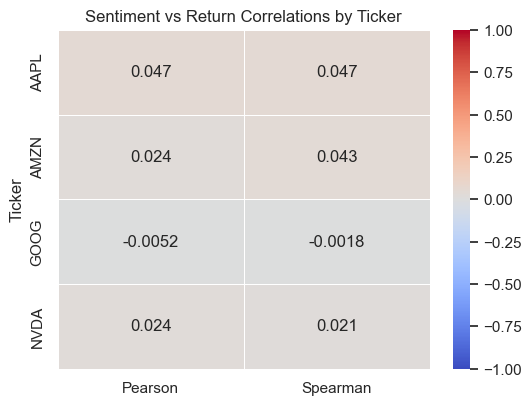

In [13]:
# Visualize Correlation Matrix
if not corr_df.empty:
    plt.figure(figsize=(6, len(corr_df) * 0.6 + 2))
    sns.heatmap(corr_df[['Pearson', 'Spearman']], annot=True, vmin=-1, vmax=1, cmap='coolwarm', linewidths=0.5)
    plt.title('Sentiment vs Return Correlations by Ticker')
    plt.show()
else:
    print("Correlation DataFrame is empty; no heatmap to display.")